In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

In [2]:
df = pd.read_csv('../data/raw/train.csv')
print(df.shape)
df.head()

(1460, 81)


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

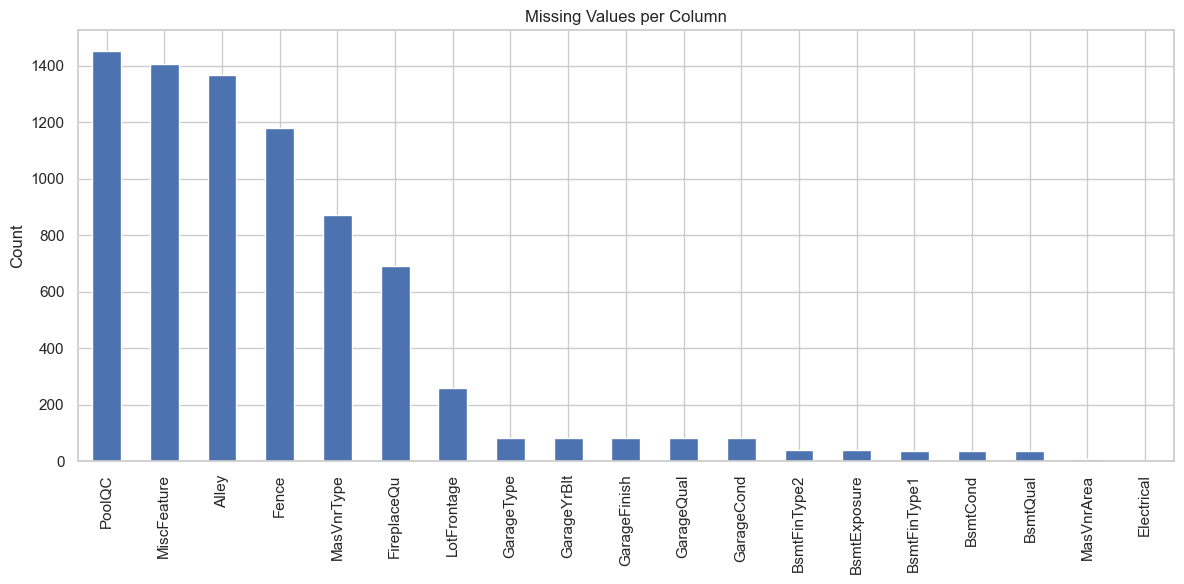

In [4]:
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)

plt.figure(figsize=(12, 6))
missing.plot(kind='bar')
plt.title('Missing Values per Column')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

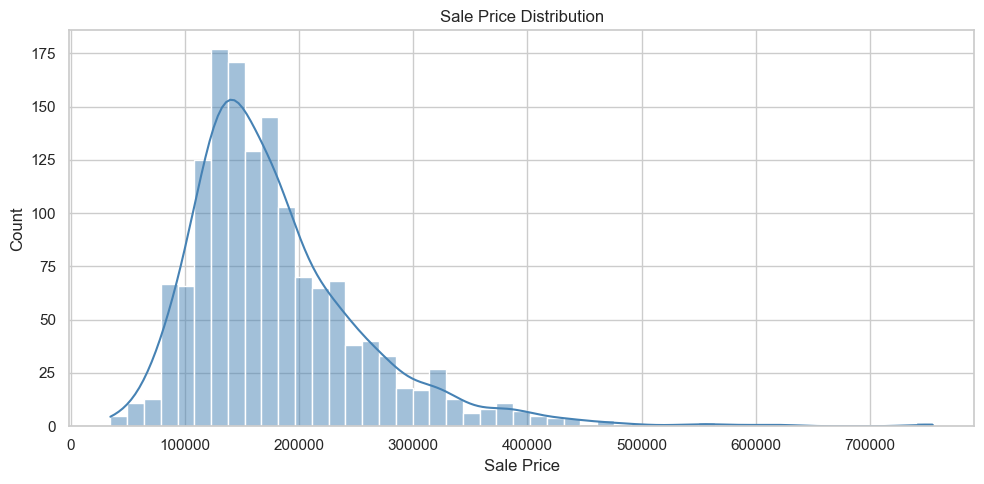

count      1460.000000
mean     180921.195890
std       79442.502883
min       34900.000000
25%      129975.000000
50%      163000.000000
75%      214000.000000
max      755000.000000
Name: SalePrice, dtype: float64


In [5]:
plt.figure(figsize=(10, 5))
sns.histplot(df['SalePrice'], kde=True, color='steelblue')
plt.title('Sale Price Distribution')
plt.xlabel('Sale Price')
plt.tight_layout()
plt.show()

print(df['SalePrice'].describe())

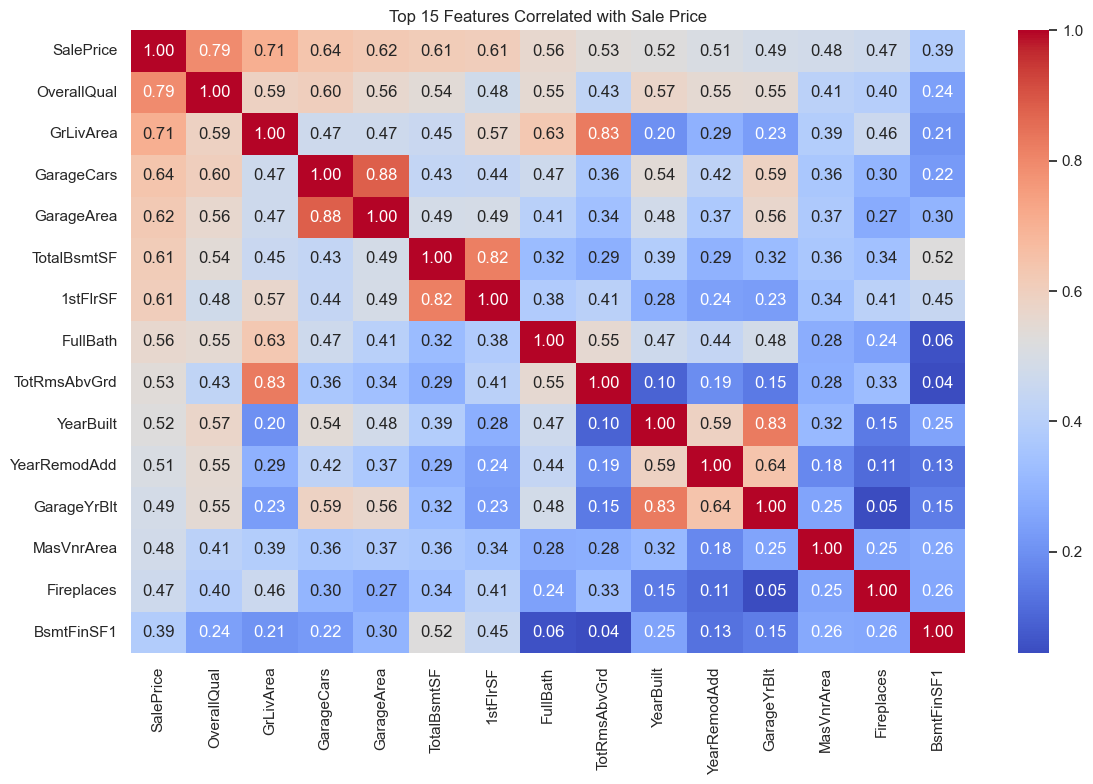

In [6]:
numeric_df = df.select_dtypes(include=[np.number])
top_corr = numeric_df.corr()['SalePrice'].abs().sort_values(ascending=False).head(15).index

plt.figure(figsize=(12, 8))
sns.heatmap(numeric_df[top_corr].corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Top 15 Features Correlated with Sale Price')
plt.tight_layout()
plt.show()

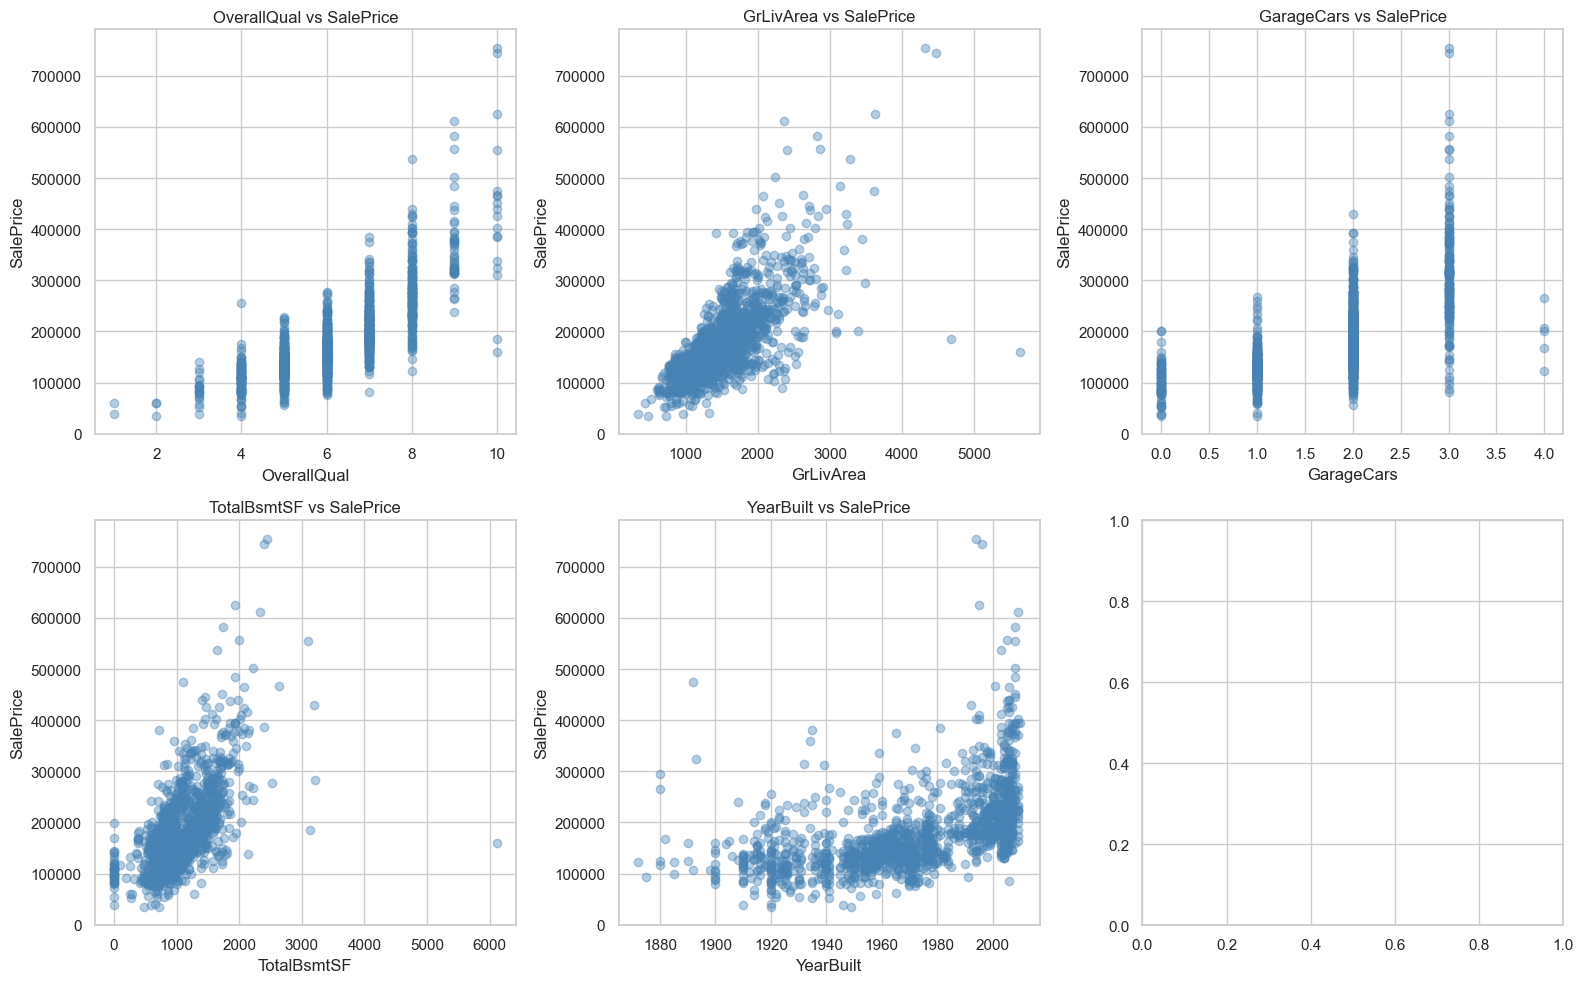

In [7]:
top_features = ['OverallQual', 'GrLivArea', 'GarageCars', 'TotalBsmtSF', 'YearBuilt']

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, feat in enumerate(top_features):
    axes[i].scatter(df[feat], df['SalePrice'], alpha=0.4, color='steelblue')
    axes[i].set_xlabel(feat)
    axes[i].set_ylabel('SalePrice')
    axes[i].set_title(f'{feat} vs SalePrice')

plt.tight_layout()
plt.show()

/var/folders/mr/42m4gcl55yxfm2sqj6rqwy5m0000gn/T/ipykernel_51034/1262915176.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Neighborhood', y='SalePrice', order=order, palette='coolwarm')


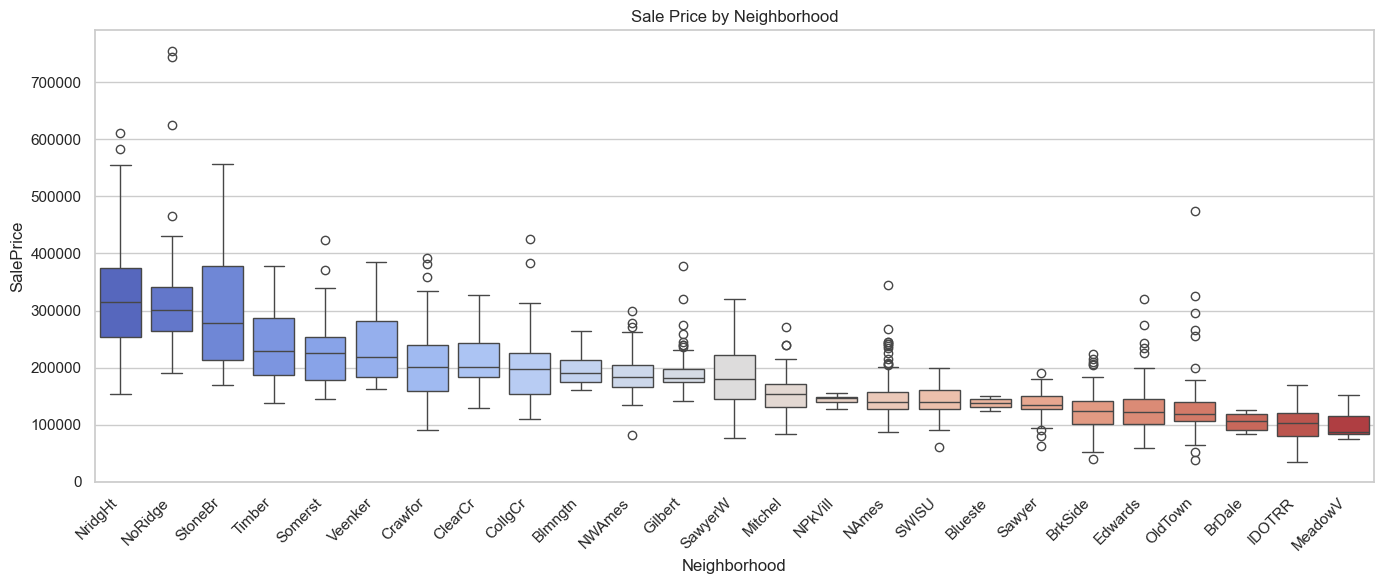

In [8]:
plt.figure(figsize=(14, 6))
order = df.groupby('Neighborhood')['SalePrice'].median().sort_values(ascending=False).index
sns.boxplot(data=df, x='Neighborhood', y='SalePrice', order=order, palette='coolwarm')
plt.xticks(rotation=45, ha='right')
plt.title('Sale Price by Neighborhood')
plt.tight_layout()
plt.show()